<a href="https://colab.research.google.com/github/Sadiestar/analyse-immobilier-python/blob/main/P8_Student_Version_V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent.

In [ ]:
# On importe les librairies necessaires pour traiter les données et les visualiser
# Manipulation de données tabulaires
import pandas as pd

# Calcul numérique et mathématique
import numpy as np

# Module de création de graphiques
import matplotlib.pyplot as plt
# Permet de personnaliser les axes d'un graphique
import matplotlib.ticker as ticker

In [ ]:
# Chargement du fichier Excel à partir de Github
url = 'https://raw.githubusercontent.com/Sadiestar/analyse-immobilier-python/main/historique_immobilier_paris_2017_2021_vdef2.xlsx'
df = pd.read_excel(url)

# Aperçu des données
df.head()

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


In [ ]:
# Dimensions du dataframe
print(f'Nombre de lignes : {df.shape[0]:,}'.replace(',', ' '))
print(f'Nombre de colonnes : {df.shape[1]}')

#On vérifie que le type des données attribué par pandas est cohérent
df.info()

Nombre de lignes : 26 196
Nombre de colonnes : 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26196 non-null  datetime64[ns]
 1   valeur_fonciere   26196 non-null  float64       
 2   adresse_numero    26196 non-null  int64         
 3   adresse_nom_voie  26196 non-null  object        
 4   code_postal       26196 non-null  int64         
 5   nom_commune       26196 non-null  object        
 6   code_type_local   26196 non-null  int64         
 7   type_local        26196 non-null  object        
 8   surface_reelle    26196 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8+ MB


Le jeu de données contient 26 196 observations, décrites par 9 variables.
Chaque ligne correspond à une transaction immobilière.

### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [ ]:
types_biens = df['type_local'].dropna().unique()
print('Liste des types de biens présents dans les données :')
for type_bien in types_biens:
    print('-', type_bien)

Liste des types de biens présents dans les données :
- Appartement
- Local industriel. commercial ou assimilé


### 3. Nombre de transactions

In [ ]:
# Nombre total de transactions
print("Le nombre de transactions dans les données est :")
print(len(df))

# Nombre de transactions pour les appartements
print("\nLe nombre de transactions pour les appartements dans les données est :")
print(len(df[df["type_local"] == "Appartement"]))

# Nombre de transactions pour les locaux commerciaux
print("\nLe nombre de transactions pour les locaux commerciaux dans les données est :")
print(len(df[df["type_local"] == "Local industriel. commercial ou assimilé"]))

Le nombre de transactions dans les données est :
26196

Le nombre de transactions pour les appartements dans les données est :
24353

Le nombre de transactions pour les locaux commerciaux dans les données est :
1843


### 4. interval de l'historique des données

In [ ]:
date_min = df['date_mutation'].min()
date_max = df['date_mutation'].max()

print(f"Première transaction enregistrée : {date_min:%d/%m/%Y}")
print(f"Dernière transaction enregistrée : {date_max:%d/%m/%Y}")

Première transaction enregistrée : 02/01/2017
Dernière transaction enregistrée : 31/12/2021


Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [ ]:
# Calcul de la colonne
df['prix_m2'] = (
    df['valeur_fonciere']
    / df['surface_reelle']
)
# Vérification
df[['valeur_fonciere',
    'surface_reelle',
    'prix_m2']].head()

,valeur_fonciere,surface_reelle,prix_m2
0,5.505597e+05,50,11011.193562
1,1.576492e+06,163,9671.732877
2,6.577574e+05,66,9966.020548
3,2.500868e+05,22,11367.582877
4,1.762667e+05,15,11751.113836


Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [ ]:
# Filtrage des appartements et sélection des colonnes utiles
df['arrondissement'] = df['code_postal'].astype(str).str[-2:]
df['annee'] = df['date_mutation'].dt.year

df_appartements = df.loc[
    df['type_local'] == 'Appartement',
    [
        'annee',
        'valeur_fonciere',
        'prix_m2',
        'surface_reelle',
        'code_postal',
        'arrondissement',
        'adresse_numero',
        'adresse_nom_voie'


    ]
].copy()

df_appartements.head()

,annee,valeur_fonciere,prix_m2,surface_reelle,code_postal,arrondissement,adresse_numero,adresse_nom_voie
0,2017,5.505597e+05,11011.193562,50,75003,03,8,RUE DES COUTURES SAINT GERVAIS
1,2017,1.576492e+06,9671.732877,163,75008,08,32,AV MARCEAU
2,2017,6.577574e+05,9966.020548,66,75008,08,52,RUE DU FAUBOURG SAINT HONORE
3,2017,2.500868e+05,11367.582877,22,75003,03,64,RUE DU VERTBOIS
4,2017,1.762667e+05,11751.113836,15,75001,01,25,RUE DES LAVANDIERES STE OPPORT


In [ ]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée

# Regroupement par année
df_prix_annuel = (
    df_appartements
    .groupby('annee')
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        surface_moyenne=('surface_reelle', 'mean'),
        nb_transactions=('prix_m2', 'count')
    )
    .round(2)
    .reset_index()
)

df_prix_annuel

,annee,prix_m2_moyen,surface_moyenne,nb_transactions
0,2017,9492.86,44.63,5206
1,2018,10031.40,44.27,5076
2,2019,10562.71,43.36,5251
3,2020,10674.87,42.90,4127
4,2021,10455.60,43.48,4693


In [ ]:
# Evolution du prix moyen des appartements au m2 entre 2017 et 2021
prix_2017 = df_prix_annuel.loc[df_prix_annuel['annee'] == 2017, 'prix_m2_moyen'].iloc[0]
prix_2021 = df_prix_annuel.loc[df_prix_annuel['annee'] == 2021, 'prix_m2_moyen'].iloc[0]
evolution_pct = (prix_2021 / prix_2017 - 1) * 100

print(f'Prix moyen au m² en 2017 : {prix_2017:,.0f} €'.replace(',', ' '))
print(f'Prix moyen au m² en 2021 : {prix_2021:,.0f} €'.replace(',', ' '))
print(f'Évolution entre 2017 et 2021 : {evolution_pct:.1f} %')

Prix moyen au m² en 2017 : 9 493 €
Prix moyen au m² en 2021 : 10 456 €
Évolution entre 2017 et 2021 : 10.1 %


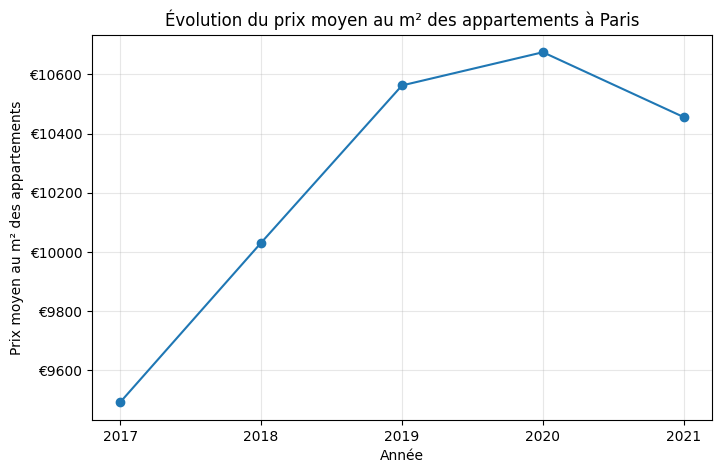

In [ ]:
# Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(8,5))

plt.plot(df_prix_annuel['annee'], df_prix_annuel['prix_m2_moyen'], marker='o')
plt.xlabel('Année')
plt.ylabel('Prix moyen au m² des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Forcer les graduations à être des entiers
plt.title('Évolution du prix moyen au m² des appartements à Paris')
plt.show()

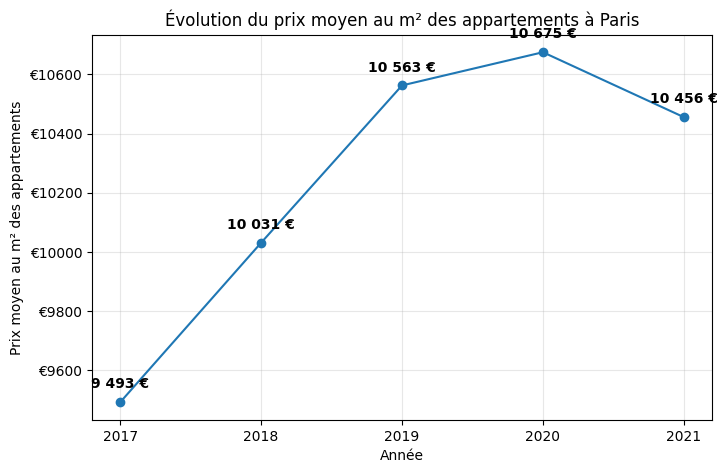

In [ ]:
# Ajouter les valeurs des points de données
plt.figure(figsize=(8,5))

plt.plot(
    df_prix_annuel['annee'],
    df_prix_annuel['prix_m2_moyen'],
    marker='o'
)

# Affichage des valeurs sur chaque point
for x, y in zip(
    df_prix_annuel['annee'],
    df_prix_annuel['prix_m2_moyen']
):
    plt.annotate(
        f"{y:,.0f} €".replace(",", " "),
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel("Année")
plt.ylabel("Prix moyen au m² des appartements")

formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(alpha=0.3)

plt.gca().xaxis.set_major_locator(
    ticker.MaxNLocator(integer=True)
)

plt.title("Évolution du prix moyen au m² des appartements à Paris")

plt.show()

On constate une augmentation progressive du prix moyen au mètre carré des appartements parisiens entre 2017 et 2020, passant de 9 493 €/m² à 10 675 €/m². Cette évolution traduit une forte valorisation du marché immobilier parisien sur cette période. En 2021, une légère baisse est observée, mais les prix restent globalement élevés.

### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [ ]:
# Liste des codes postaux présents dans les données
arrondissements = sorted(df_appartements['arrondissement'].unique())

print("Liste des arrondissements présents dans les données :")
for arr in arrondissements:
    print("-", arr)

Liste des arrondissements présents dans les données :
- 01
- 02
- 03
- 04
- 05
- 06
- 07
- 08
- 09
- 10
- 11
- 12
- 13
- 14
- 15
- 16
- 17
- 18
- 19
- 20


In [ ]:
# Créons un DataFrame pour une deuxième visualisation montrant l'évolution des prix par arrondissement
prix_appartements_arrondissement = (
    df_appartements
    .groupby(['arrondissement', 'annee'], as_index=False)
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        nombre_transactions=('prix_m2', 'size')
    )
)

prix_appartements_arrondissement.head()

,arrondissement,annee,prix_m2_moyen,nombre_transactions
0,01,2017,11762.706289,87
1,01,2018,12621.226146,98
2,01,2019,13269.256149,91
3,01,2020,13405.991820,70
4,01,2021,13379.498578,63


In [ ]:
# Filtrer le 1er arrondissement et regrouper par la moyenne du prix au m2 par année
df_1er = df.loc[
    (df['arrondissement'] == '01')
].copy()

df_evolution_1er = (
    df_1er
    .groupby('annee')
    .agg(prix_m2_moyen=('prix_m2', 'mean'))
    .round(2)
    .reset_index()
)

df_evolution_1er

,annee,prix_m2_moyen
0,2017,11922.19
1,2018,12818.04
2,2019,13458.52
3,2020,13461.84
4,2021,13602.67


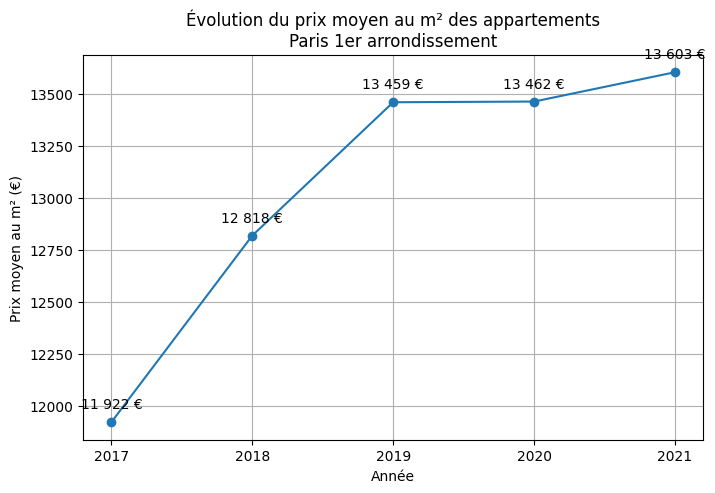

In [ ]:
# Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement avec les valeurs des points de données
plt.figure(figsize=(8,5))

plt.plot(
    df_evolution_1er['annee'],
    df_evolution_1er['prix_m2_moyen'],
    marker='o'
)

# Affichage des valeurs sur les points
for x, y in zip(df_evolution_1er['annee'],
                df_evolution_1er['prix_m2_moyen']):
    plt.annotate(
        f"{y:,.0f} €".replace(",", " "),
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

plt.title("Évolution du prix moyen au m² des appartements\nParis 1er arrondissement")
plt.xlabel("Année")
plt.ylabel("Prix moyen au m² (€)")
plt.gca().xaxis.set_major_locator(
    ticker.MaxNLocator(integer=True)
)
plt.grid(True)

plt.show()

Le prix moyen au mètre carré des appartements du 1er arrondissement de Paris affiche une tendance globalement haussière sur la période 2017-2021. L'augmentation est particulièrement marquée entre 2017 et 2019, avant une phase de stabilisation en 2020, suivie d'une légère reprise en 2021. Cette évolution reflète l'attractivité et la valorisation continues du marché immobilier de cet arrondissement, dont les prix restent parmi les plus élevés de Paris. Contrairement à la tendance observée à l'échelle de l'ensemble des appartements parisiens, aucune baisse des prix n'est constatée entre 2020 et 2021 dans le 1er arrondissement.

Nous allons ajouter à cette visualisation tous les autres arrondissements avec une couleur différente.

In [ ]:
# Tableau pivot : lignes = années, colonnes = arrondissements
df_pivot_arrondissement = prix_appartements_arrondissement.pivot(
    index='annee',
    columns='arrondissement',
    values='prix_m2_moyen'
)

df_pivot_arrondissement

arrondissement,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16,17,18,19,20
annee,,,,,,,,,,,,,,,,,,,,
2017,11762.706289,10920.126562,11679.818729,12407.227522,11306.752404,12508.837036,11845.118831,10132.798372,9582.311203,8747.004273,9137.783721,8454.848964,8344.893374,9054.806033,9097.893718,9808.824060,9336.868287,8466.296314,7621.764808,7886.023336
2018,12621.226146,11309.461297,12469.997687,13431.886791,12056.438160,12896.276640,12553.177030,10631.299183,10187.210521,9328.031275,9688.945219,8937.726508,8755.219424,9433.545087,9328.040835,10244.444401,9880.663007,9152.933880,8265.857054,8485.162808
2019,13269.256149,12150.543211,12813.403980,13641.494658,12928.383859,13378.073631,12921.892652,11195.449314,10957.783651,9999.125882,10376.908666,9497.677106,9340.366016,10027.167999,9822.107561,10825.033083,10399.607301,9928.336981,8850.261628,9093.992492
2020,13405.991820,12181.589810,12834.313205,13104.738603,12959.757302,13807.087614,13109.829386,11702.927736,10981.242522,10200.332358,10533.071590,9691.106390,9333.897460,10107.800126,10061.238564,10911.135562,10536.288246,9946.886945,8982.620746,9329.305302
2021,13379.498578,11773.445419,12660.546567,12936.958334,12605.843983,13795.048958,13118.135985,11710.094574,10732.184387,10043.466941,10351.644701,9657.980179,9164.625982,9993.616203,9971.240600,10790.307817,10372.368746,9665.640629,8828.586057,9114.398249


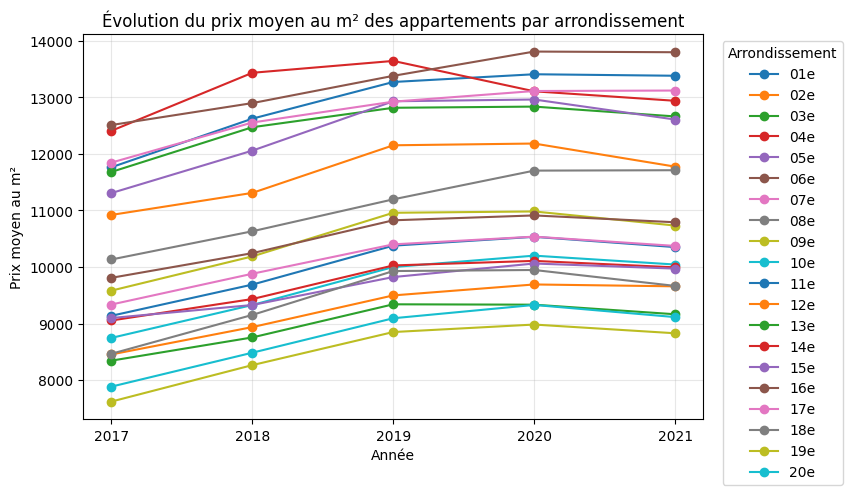

In [ ]:
# Visualisation de l'évolution du prix moyen au m2 des appartements par arrondissement
plt.figure(figsize=(8,5))
for arrondissement in df_pivot_arrondissement.columns:
    plt.plot(df_pivot_arrondissement.index, df_pivot_arrondissement[arrondissement], marker='o', label=f'{arrondissement}e')

plt.xlabel('Année')
plt.ylabel('Prix moyen au m²')
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Forcer les graduations à être des entiers
plt.title('Évolution du prix moyen au m² des appartements par arrondissement')
plt.legend(title='Arrondissement', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### 7. Prix au metre carré par transaction dans le 6 ème arrondissement

In [ ]:
# Analyse univariée du prix moyen au m2 dans le 6 ème
cp = 75006
df_75006 = df[
    (df['code_postal'] == cp) &
    (df['type_local'] == 'Appartement')
]
df_75006 ['prix_m2'].describe()

,prix_m2
count,709.000000
mean,13143.507482
std,565.780964
min,12065.237671
25%,12647.673288
50%,13122.725342
75%,13631.590411
max,14169.817123


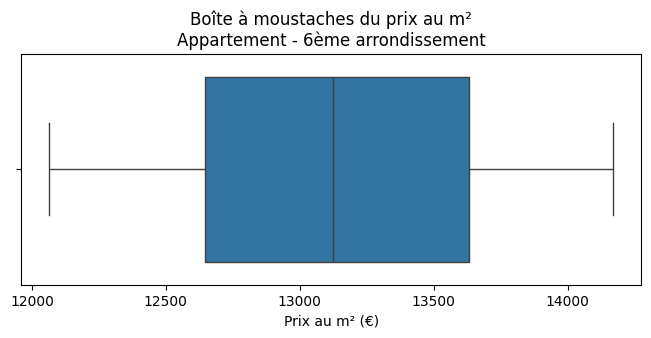

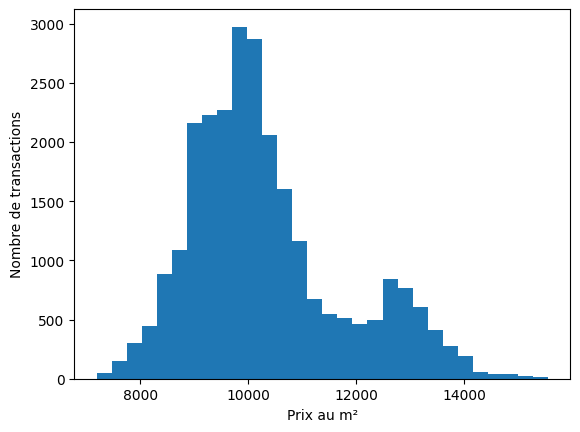

In [ ]:
# Boite à moustache
import seaborn as sns

plt.figure(figsize=(8, 3))
sns.boxplot(
    x=df_75006['prix_m2']
)

plt.title("Boîte à moustaches du prix au m²\nAppartement - 6ème arrondissement")
plt.xlabel("Prix au m² (€)")
plt.show()

# Histogramme de distribution
plt.hist(df['prix_m2'], bins=30)
plt.xlabel("Prix au m²")
plt.ylabel("Nombre de transactions")
plt.show()

L'analyse statistique des transactions du 6ᵉ arrondissement montre que le prix moyen au mètre carré élevé n'est pas dû à un faible nombre de ventes ou à quelques transactions atypiques. Avec 709 transactions, un prix moyen très proche de la médiane et une dispersion relativement faible, les prix apparaissent homogènes. Le niveau élevé du prix au mètre carré reflète donc bien la réalité du marché immobilier du 6ᵉ arrondissement, qui figure parmi les secteurs les plus valorisés de Paris.

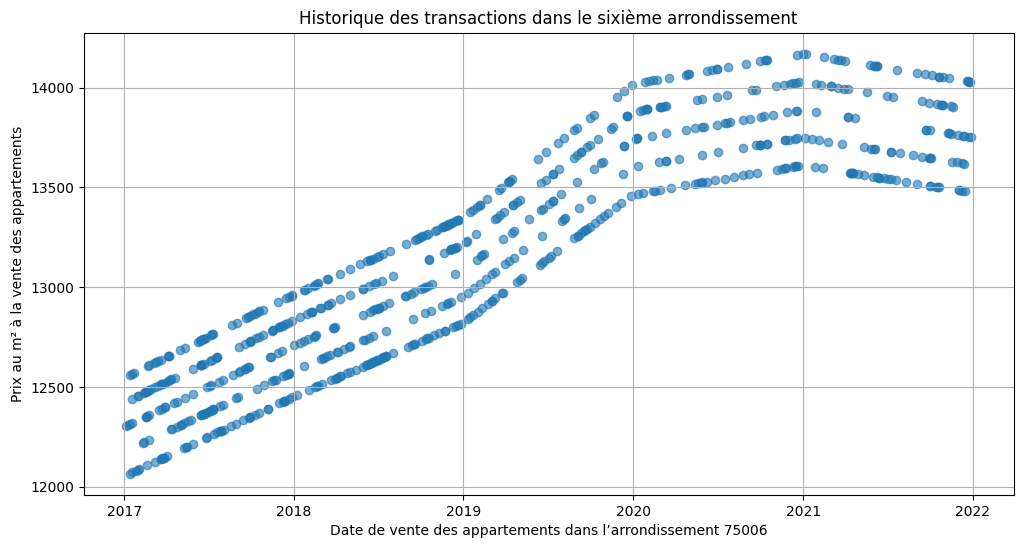

In [ ]:
# Affichage d'un visuel en nuage de point
plt.figure(figsize=(12, 6))

plt.scatter(
    df_75006['date_mutation'],
    df_75006['prix_m2'],
    alpha=0.6
)

plt.xlabel('Date de vente des appartements dans l’arrondissement 75006')
plt.ylabel('Prix au m² à la vente des appartements')

plt.grid(True)

plt.title('Historique des transactions dans le sixième arrondissement')

plt.show()

L'historique des transactions du 6ᵉ arrondissement met en évidence une augmentation régulière du prix au mètre carré entre 2017 et 2021. Les transactions sont nombreuses et réparties de manière homogène, sans présence de valeurs aberrantes susceptibles de biaiser les résultats. Cette analyse confirme que le niveau élevé du prix moyen observé dans le 6ᵉ arrondissement reflète bien la réalité du marché immobilier local. On observe toutefois une tendance à la stabilisation des prix à partir de 2020, après plusieurs années de forte progression.

Rq : La forme en plusieurs courbes parallèles est inhabituelle pour des données réelles.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson

Nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [ ]:
df_75006 = df_75006.copy()

# Conversion des dates en nombre de jours depuis une origine
df_75006['date_num'] = (
    pd.to_datetime(df_75006['date_mutation'])
    .map(pd.Timestamp.toordinal)
)
from scipy.stats import pearsonr
df_75006['date_num']
coef, p_value = pearsonr(
    df_75006['date_num'],
    df_75006['prix_m2']
)

print(f"Coefficient de corrélation : {coef:.4f}")
print(f"p-value : {p_value:.4e}")

Coefficient de corrélation : 0.9038
p-value : 7.1084e-263


Le coefficient de corrélation de Pearson entre la date de transaction et le prix au mètre carré est de 0,9038, ce qui traduit une très forte corrélation positive. La p-value de 7,1 × 10⁻²⁶³, très largement inférieure au seuil de significativité de 5 %, indique que cette corrélation est statistiquement significative. Nous pouvons donc conclure que le temps exerce une influence importante sur le prix au mètre carré des appartements dans le 6ᵉ arrondissement de Paris : les prix ont globalement augmenté au cours de la période étudiée.

### 9. Vérification de la relation entre la valeur fonciere et la surface

In [ ]:
# On reprend le data frame de tous les appartements parisiens
coef, p_value = pearsonr(
    df_appartements['surface_reelle'],
    df_appartements['valeur_fonciere']
)

print(f"Coefficient de corrélation : {coef:.4f}")
print(f"p-value : {p_value:.4e}")

Coefficient de corrélation : 0.9801
p-value : 0.0000e+00


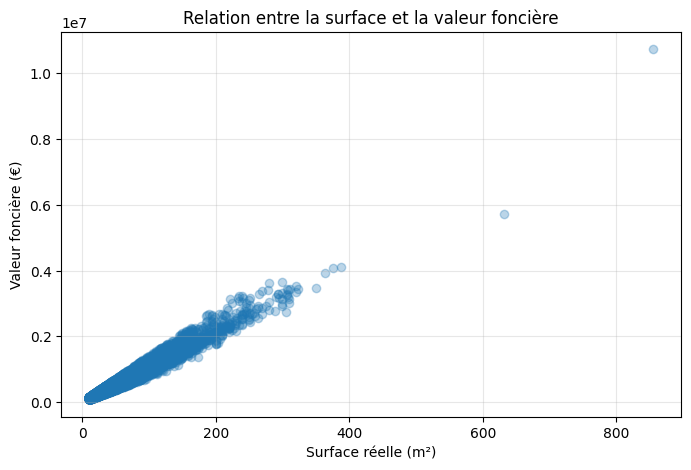

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_appartements['surface_reelle'],
    df_appartements['valeur_fonciere'],
    alpha=0.3
)

plt.xlabel("Surface réelle (m²)")
plt.ylabel("Valeur foncière (€)")
plt.title("Relation entre la surface et la valeur foncière")
plt.grid(alpha=0.3)

plt.show()

Le coefficient de corrélation de Pearson entre la surface réelle et la valeur foncière est de 0,9801, avec une p-value proche de zéro. Cette corrélation très forte et statistiquement significative confirme que la surface est un facteur déterminant du prix de vente des appartements. Plus un appartement est grand, plus sa valeur foncière est élevée. Cette relation est cohérente avec le fonctionnement du marché immobilier, où la surface constitue l'un des principaux critères de valorisation d'un bien.

Après avoir analysé l'influence du temps et de la surface sur les prix immobiliers, nous allons vérifier si le type de bien constitue également un facteur explicatif du prix au mètre carré. Pour cela, nous comparerons les prix moyens au mètre carré des différents types de biens présents dans notre jeu de données. Cette analyse permettra de déterminer si certaines catégories de biens sont globalement plus valorisées que d'autres.

In [ ]:
# Calcul du prix moyen au m² par type de bien
df_prix_m2_type = (
    df.groupby('type_local')
      .agg(
          prix_m2_moyen=('prix_m2', 'mean'),
          nb_transactions=('prix_m2', 'count')
      )
      .round(2)
      .sort_values('prix_m2_moyen', ascending=False)
)

df_prix_m2_type

,prix_m2_moyen,nb_transactions
type_local,,
Local industriel. commercial ou assimilé,11705.02,1843
Appartement,10221.63,24353


L'analyse du prix moyen au mètre carré par type de bien montre que les locaux industriels, commerciaux ou assimilés affichent un prix moyen au mètre carré d'environ 11 705 €, contre 10 222 € pour les appartements. Le type de bien semble donc avoir une influence sur le prix au mètre carré. Les locaux commerciaux apparaissent globalement plus valorisés que les appartements dans les données étudiées. Cette différence peut s'expliquer par la localisation stratégique de certains locaux professionnels et leur potentiel économique.

### 10. Analyse des locaux industriels, commerciaux et assimilés

In [ ]:
# On crée un dataset qui ne contient que les locaux industriels,commerciaux ou assimilés
df_locaux = df.loc[
    df['type_local'] == 'Local industriel. commercial ou assimilé',
    [
        'date_mutation',
        'annee',
        'valeur_fonciere',
        'prix_m2',
        'surface_reelle',
        'code_postal',
        'arrondissement'
    ]
].copy()

df_locaux.head()

,date_mutation,annee,valeur_fonciere,prix_m2,surface_reelle,code_postal,arrondissement
18,2017-02-01,2017,3.113277e+06,12453.109192,250,75003,03
29,2017-02-17,2017,1.164375e+06,12256.581685,95,75003,03
34,2017-02-20,2017,3.802522e+05,12266.199603,31,75003,03
91,2017-03-09,2017,3.623842e+05,12496.006027,29,75001,01
109,2017-03-29,2017,3.159072e+05,12636.289027,25,75003,03


In [ ]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année
df_prix_annuel_locaux = (
    df_locaux
    .groupby('annee')
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        surface_moyenne=('surface_reelle', 'mean'),
        nb_transactions=('prix_m2', 'count')
    )
    .round(2)
    .reset_index()
)

df_prix_annuel_locaux

,annee,prix_m2_moyen,surface_moyenne,nb_transactions
0,2017,10949.91,89.99,349
1,2018,11569.50,88.10,351
2,2019,11960.13,82.83,432
3,2020,11966.47,85.63,336
4,2021,12006.49,92.83,375


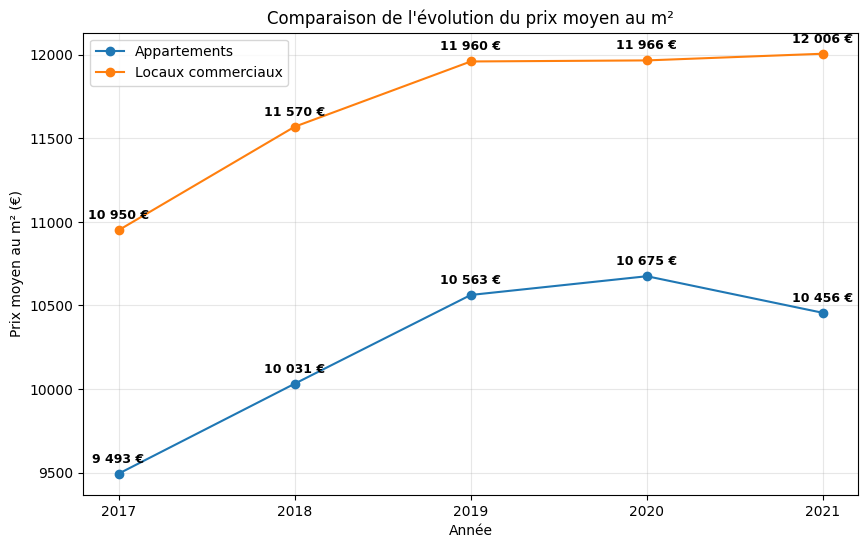

In [ ]:
# Création d'un graphique pour visualiser la hausse de la moyenne des prix appartements vs locaux avec les valeurs des points de données

plt.figure(figsize=(10,6))

# Appartements
plt.plot(
    df_prix_annuel['annee'],
    df_prix_annuel['prix_m2_moyen'],
    marker='o',
    label='Appartements'
)

# Valeurs des appartements
for x, y in zip(
    df_prix_annuel['annee'],
    df_prix_annuel['prix_m2_moyen']
):
    plt.annotate(
        f"{y:,.0f} €".replace(",", " "),
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Locaux commerciaux
plt.plot(
    df_prix_annuel_locaux['annee'],
    df_prix_annuel_locaux['prix_m2_moyen'],
    marker='o',
    label='Locaux commerciaux'
)

# Valeurs des locaux commerciaux
for x, y in zip(
    df_prix_annuel_locaux['annee'],
    df_prix_annuel_locaux['prix_m2_moyen']
):
    plt.annotate(
        f"{y:,.0f} €".replace(",", " "),
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel('Année')
plt.ylabel('Prix moyen au m² (€)')
plt.title("Comparaison de l'évolution du prix moyen au m²")
plt.xticks([2017, 2018, 2019, 2020, 2021])
plt.grid(alpha=0.3)
plt.legend()

plt.show()

Les locaux industriels, commerciaux et assimilés présentent un prix moyen au mètre carré supérieur à celui des appartements sur l'ensemble de la période étudiée. Les deux catégories de biens connaissent une hausse globale des prix entre 2017 et 2021, mais l'augmentation est plus régulière pour les locaux commerciaux. Cela suggère que le type de bien influence significativement le prix au mètre carré.

Pour prédire le prix au mètre carré d'un bien immobilier, les variables les plus pertinentes identifiées lors de cette analyse sont :

- la surface du bien immobilier ;
- la date de transaction ;
- la localisation du bien (code postal ou arrondissement) ;
- le type de bien.
  
Ces variables constitueront les principales caractéristiques du futur modèle de prédiction

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrainer un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer les données en transformant les variables catégorielles de l'arrondissement et du type de local grâce à "get_dummies" (pandas)

On repart du dataframe complet et on conserve les variables identifiées comme utiles dans le milestone 1
- Variables explicatives : surface, date, arrondissement, type de bien, date
- Variable cible : valeur foncière


In [ ]:
# Préparation des données
df_model = df.copy()

df_model['date_num'] = df_model['date_mutation'].map(pd.Timestamp.toordinal) #transformation de la date en nombre

features_numeriques = ['surface_reelle', 'date_num']
features_categorielles = ['arrondissement', 'type_local']

# Construction de la matrice d'apprentissage X (variables explicatives)
X = pd.get_dummies(                                          #pour créer des colonnes binaires (0 ou 1).
    df_model[features_numeriques + features_categorielles],
    columns=features_categorielles,                          #Encodage des variables catégorielles
    drop_first=False                                         #conserver toutes les catégories.
)
# Cible de prédiction y (variable cible)
y = df_model['valeur_fonciere']

# On garde la liste des colonnes pour pouvoir réutiliser exactement la même structure lors des prédictions
colonnes_modele = X.columns

print('Dimensions de X :', X.shape)
print('Dimensions de y :', y.shape)
X.head()

Dimensions de X : (26196, 24)
Dimensions de y : (26196,)


,surface_reelle,date_num,arrondissement_01,arrondissement_02,arrondissement_03,arrondissement_04,arrondissement_05,arrondissement_06,arrondissement_07,arrondissement_08,...,arrondissement_13,arrondissement_14,arrondissement_15,arrondissement_16,arrondissement_17,arrondissement_18,arrondissement_19,arrondissement_20,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,50,736332,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,163,736341,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,66,736339,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,22,736339,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,15,736342,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
y.head()

,valeur_fonciere
0,5.505597e+05
1,1.576492e+06
2,6.577574e+05
3,2.500868e+05
4,1.762667e+05


On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [ ]:
# On sépare le jeu de données entre echantillons d'apprentissage (train) et de test

# Cette fonction permet de découper les données en deux parties
from sklearn.model_selection import train_test_split

# Ces fonctions serviront plus tard à mesurer la qualité des prédictions (erreur moyenne, ereur moyenne %, coéfficient de détermination)
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,                                         # 33% de l'échantillon réservé au test (8645 transactions) , 67 % à l'apprentissage (17551 observations)
    random_state=42                                         # Fixe le tirage aléatoire pour toujours donner  exactement les mêmes jeux train/test
)

print('Taille du jeu d\'entraînement :', X_train.shape[0], 'lignes')
print(X_train.dtypes.value_counts())
print('Taille du jeu de test :', X_test.shape[0], 'lignes')

Taille du jeu d'entraînement : 17551 lignes
bool     22
int64     2
Name: count, dtype: int64
Taille du jeu de test : 8645 lignes


Le modèle apprendra sur 17 551 transactions et sera évalué sur environ 8 645 transactions qu'il n'a jamais vues. C'est cette étape qui permet de mesurer objectivement la capacité du modèle à prédire la valeur foncière de nouveaux biens.

In [ ]:
# On entraîne l'algorithme et on effectue la prédiction

# On importe l'algorithme de régression linéaire. Son objectif est de trouver une formule du type : Valeur_fonciere = a×surface + b×date + c×arrondissement + d×type_local+ e (a, b, c, d sont les coefficients appris, e l'intercept )
from sklearn.linear_model import LinearRegression

# Entraînement de l'algorithme
modele_regression = LinearRegression()   # Modele vide
modele_regression.fit(X_train, y_train)  # Le modèle analyse les 17 551 transactions du jeu d'entraînement et cherche quelles sont les variables qui expliquent le mieux la valeur foncière.

# Prédiction sur le jeu de test
y_pred = modele_regression.predict(X_test)

# Mesure de la performance : on compare les predictions obtenues (y_pred), avec les valeurs réelles de y_test
mae = mean_absolute_error(y_test, y_pred)                    # erreur absolue moyenne (MAE)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # ereur moyenne en % (MAPE)
r2 = r2_score(y_test, y_pred)                                # coéfficient de détermination R² mesure la part de la variance expliquée par le modèle

print(f'Erreur absolue moyenne : {mae:,.0f} €'.replace(',', ' '))
print(f'Erreur moyenne en pourcentage : {mape:.2f} %')
print(f'Coefficient de détermination R² : {r2:.3f}')

# Tableau de contrôle des premières prédictions
resultats_test = pd.DataFrame({
    'valeur_reelle': y_test,
    'valeur_predite': y_pred,
    'erreur_absolue': abs(y_test - y_pred),
    'erreur_pct': abs(y_test - y_pred) / y_test * 100
}).round(2)

resultats_test.head(10)

Erreur absolue moyenne : 34 434 €
Erreur moyenne en pourcentage : 9.53 %
Coefficient de détermination R² : 0.986


,valeur_reelle,valeur_predite,erreur_absolue,erreur_pct
7178,228793.95,211984.48,16809.48,7.35
10733,213326.69,274888.48,61561.79,28.86
20031,290498.70,274788.47,15710.24,5.41
9698,704732.60,785207.57,80474.97,11.42
18238,869560.79,896763.46,27202.67,3.13
19859,298730.65,280762.11,17968.54,6.01
19636,928685.90,945122.09,16436.19,1.77
959,290056.95,353286.22,63229.27,21.80
7131,157561.50,135921.39,21640.10,13.73
9577,763012.09,773987.15,10975.06,1.44


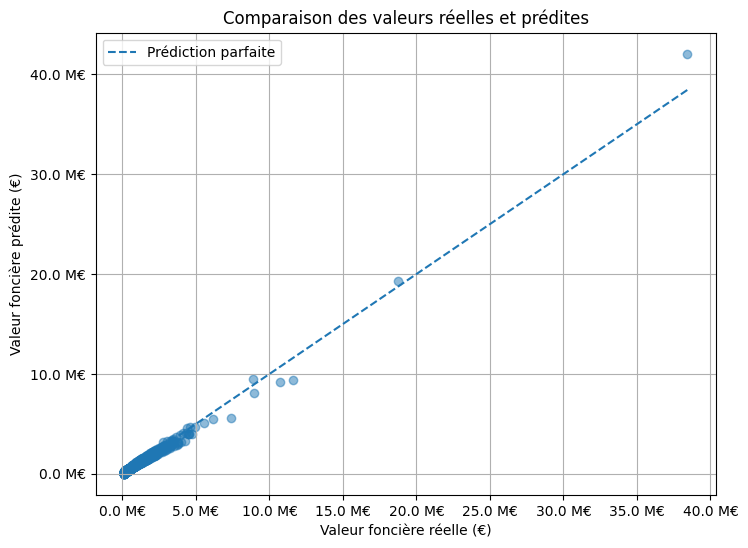

In [ ]:
# Visualisation de la comparaison des valeurs réelles et prédites
from matplotlib.ticker import FuncFormatter                      #  ppersonnalisation de l'affichage des axes

plt.figure(figsize=(8, 6))


plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    label="Prédiction parfaite"
)

plt.title("Comparaison des valeurs réelles et prédites")
plt.xlabel("Valeur foncière réelle (€)")
plt.ylabel("Valeur foncière prédite (€)")
plt.legend()
plt.grid(True)

formatter = FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} M€')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

- L'algorithme fait une erreur moyenne inférieure à 10 %, ce qui rend les prédictions de la valeur foncières fiables.
- Le modèle de régression linéaire est suffisamment précis pour être utilisé dans la valorisation du portefeuille immobilier.
- Les résultats montrent que les variables retenues capturent l'essentiel des facteurs influençant la valeur foncière (par un excellent coefficient de détermination R² = 0,986)
- L'erreur reste toutefois importante pour certaines transactions, car le marché immobilier dépend aussi de variables absentes du jeu de données : nombre de pièces, étage, état du bien, proximité des transports...
- Pour aller plus loin, on pourrait tester des modèles plus performants comme Random Forest, Gradient Boosting ou XGBoost, et créer ces nouvelles variables explicatives.
- Le modèle suppose une relation globalement linéaire entre les variables et la valeur foncière, ce qui simplifie beaucoup la réalité du marché immobilier.

La validation croisée permet de vérifier que les performances observées ne dépendent pas d'un découpage particulier du jeu de données. Elle fournit une estimation plus fiable de la capacité du modèle à généraliser sur de nouvelles transactions immobilières.

In [ ]:
from sklearn.model_selection import cross_val_score # entraîner plusieurs fois le modèle; sur différents sous-ensembles des données; puis de calculer un score à chaque fois.

modele  = LinearRegression()

scores = cross_val_score(
    modele,
    X,
    y,
    cv=5,                # 26196 transactions ≈ 5239 lignes/Fold (5)
    scoring='r2'
)

print(scores)
print("R² moyen :", scores.mean())
print("Écart-type :", scores.std())

[0.98138071 0.97749145 0.98356934 0.97755872 0.96783454]
R² moyen : 0.9775669519181527
Écart-type : 0.0053907125277914995


La validation croisée à 5 folds confirme la robustesse du modèle de régression linéaire.

Le coefficient de détermination moyen obtenu est de 0,978, ce qui signifie que près de 98 % de la variabilité des valeurs foncières est expliquée par les variables utilisées dans le modèle.

L'écart type très faible (0,005) montre que les performances restent stables quel que soit le découpage des données. Le modèle possède une bonne capacité de généralisation.

Ces résultats confortent le choix de ce modèle pour l'estimation de la valeur des biens immobiliers du portefeuille client.

# Milestone 3 - Prédiction définitive pour le client

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez.

In [ ]:
# On importe les données du portefeuille dans un dataframe : chargement du fichier Excel à partir de Github

url2 = "https://raw.githubusercontent.com/Sadiestar/analyse-immobilier-python/main/portefeuille_actifs.xlsx"

df2 = pd.read_excel(url2)

df2.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490


In [ ]:
# Préparation des données

# Le modèle utilise surface_reelle ; le portefeuille fourni contient surface_reelle_bati
df2.rename(columns={'surface_reelle_bati': 'surface_reelle'}, inplace=True)

# Création du segment métier à partir du type de bien: les appartements relèvent du segment particulier et les locaux commerciaux du segment corporate
df2["segment"] = np.where(
    df2["type_local"] == "Appartement",
    "particulier",
    "corporate"
)
df2.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle,nombre_pieces_principales,longitude,latitude,segment
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227,particulier
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907,particulier
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318,particulier
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893,particulier
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490,particulier


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [ ]:
# On réutilise les mêmes transformations pour mettre df_prediction au même format que les données d'entraînement

import datetime as dt
DATE_PREDICTION = dt.datetime(2022, 12, 31)                                                            # On crée une date de prédiction au 31 décembre 2022

df_prediction = df2.copy()
df_prediction['date_mutation'] = DATE_PREDICTION
df_prediction['date_num'] = pd.to_datetime(df_prediction['date_mutation']).map(pd.Timestamp.toordinal) #transformation de la date en nombre
df_prediction['arrondissement'] = df_prediction['code_postal'].astype(str).str[-2:]

# Variables catégorielles transformées en colonnes (One-Hot Encoding)
X_prediction = pd.get_dummies(
    df_prediction[features_numeriques + features_categorielles],
    columns=features_categorielles,
    drop_first=False
)

# Alignement strict avec les colonnes utilisées lors de l'entraînement.
X_prediction = X_prediction.reindex(columns=colonnes_modele, fill_value=0)

print('Dimensions du dataframe de prédiction :', X_prediction.shape) # Lors de la prédiction, il faut fournir exactement les mêmes 24 colonnes, dans le même ordre
print('Dimension du jeu d\'entraînement :', X_train.shape)           # Pour mémo
X_prediction.head()

Dimensions du dataframe de prédiction : (275, 24)
Dimension du jeu d'entraînement : (17551, 24)


,surface_reelle,date_num,arrondissement_01,arrondissement_02,arrondissement_03,arrondissement_04,arrondissement_05,arrondissement_06,arrondissement_07,arrondissement_08,...,arrondissement_13,arrondissement_14,arrondissement_15,arrondissement_16,arrondissement_17,arrondissement_18,arrondissement_19,arrondissement_20,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,25,738520,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,22,738520,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,65,738520,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,74,738520,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,22,738520,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Vérification des types après transformation : toutes les variables doivent être numériques
print(X_prediction.dtypes.value_counts())

bool     22
int64     2
Name: count, dtype: int64


Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [ ]:
# On effectue la prédiction sur le portefeuille réel.
predictions_portefeuille = modele_regression.predict(X_prediction)

# Une valeur foncière négative n'aurait pas de sens métier. On borne donc les prédictions à 0 pour éviter une valorisation négative
df_prediction['valeur_fonciere_predite'] = np.maximum(predictions_portefeuille, 0)

# On vérifie les 10 premières valeurs.
colonnes_affichage = [
    'segment', 'date_mutation', 'code_postal', 'type_local',
    'surface_reelle', 'valeur_fonciere_predite'
]

df_prediction[colonnes_affichage].head(10)

,segment,date_mutation,code_postal,type_local,surface_reelle,valeur_fonciere_predite
0,particulier,2022-12-31,75001,Appartement,25,431444.348989
1,particulier,2022-12-31,75003,Appartement,22,368861.389873
2,particulier,2022-12-31,75003,Appartement,65,827086.357977
3,particulier,2022-12-31,75008,Appartement,74,878984.851836
4,particulier,2022-12-31,75008,Appartement,22,324852.332269
5,particulier,2022-12-31,75008,Appartement,35,463385.462161
6,particulier,2022-12-31,75003,Appartement,24,390174.179087
7,particulier,2022-12-31,75010,Appartement,60,642454.130391
8,particulier,2022-12-31,75017,Appartement,11,139736.784418
9,particulier,2022-12-31,75018,Appartement,13,141906.867422


In [ ]:
# Préparation du fichier des prédictions
df_prediction_export = df_prediction.copy()

colonnes_affichage = [
    'date_mutation',
    'adresse_numero',
    'adresse_nom_voie',
    'arrondissement',
    'type_local',
    'valeur_fonciere_predite',
    'surface_reelle',
    'nombre_pieces_principales',
    'longitude',
    'latitude'
]

df_prediction_export = df_prediction[colonnes_affichage]

display(df_prediction_export)


,date_mutation,adresse_numero,adresse_nom_voie,arrondissement,type_local,valeur_fonciere_predite,surface_reelle,nombre_pieces_principales,longitude,latitude
0,2022-12-31,127,RUE SAINT-DENIS,01,Appartement,431444.348989,25,1,2.349593,48.863227
1,2022-12-31,62,RUE NOTRE-DAME DE NAZARETH,03,Appartement,368861.389873,22,1,2.356977,48.867907
2,2022-12-31,62,RUE DE TURENNE,03,Appartement,827086.357977,65,3,2.364855,48.859318
3,2022-12-31,32,AV GEORGE V,08,Appartement,878984.851836,74,2,2.301586,48.868893
4,2022-12-31,152,BD HAUSSMANN,08,Appartement,324852.332269,22,1,2.311643,48.875490
...,...,...,...,...,...,...,...,...,...,...
270,2022-12-31,15,AV DE LAUMIERE,19,Local industriel. commercial ou assimilé,216410.216932,16,0,2.380450,48.883397
271,2022-12-31,3,RUE SAINT-JOSEPH,02,Local industriel. commercial ou assimilé,337576.688371,15,0,2.345110,48.868196
272,2022-12-31,2,RUE GRETRY,02,Local industriel. commercial ou assimilé,550704.580513,35,0,2.337593,48.870514
273,2022-12-31,115,RUE D ABOUKIR,02,Local industriel. commercial ou assimilé,699894.105012,49,0,2.349804,48.868784


In [ ]:
# Comparaison de la valorisation prédite par segment sur le portefeuille réel fourni
valorisation_segment = (
    df_prediction
    .groupby('segment', as_index=False)
    .agg(
        nombre_biens=('valeur_fonciere_predite', 'count'),
        surface_totale=('surface_reelle', 'sum'),
        valorisation_totale=('valeur_fonciere_predite', 'sum'),
        valorisation_moyenne=('valeur_fonciere_predite', 'mean')
    )
)

valorisation_segment['valorisation_totale_millions'] = valorisation_segment['valorisation_totale'] / 1_000_000
valorisation_segment = valorisation_segment.sort_values('valorisation_totale', ascending=False)
valorisation_segment.round(2)

,segment,nombre_biens,surface_totale,valorisation_totale,valorisation_moyenne,valorisation_totale_millions
0,corporate,121,7696,97973254.81,809696.32,97.97
1,particulier,154,6286,71053398.90,461385.71,71.05


In [ ]:
# Valorisation du portefeuille sur le segment des particuliers

val_particulier = valorisation_segment.loc[
    valorisation_segment['segment']=='particulier',
    'valorisation_totale_millions'
]

print(f"La valorisation du segment particulier est de {val_particulier.iloc[0]:.2f} millions d'euros.")

La valorisation du segment particulier est de 71.05 millions d'euros.


In [ ]:
# Valorisation du portefeuille sur le segment corporate

val_corporate = valorisation_segment.loc[
    valorisation_segment['segment']=='corporate',
    'valorisation_totale_millions'
]

print(f"La valorisation du segment corporate est de {val_corporate.iloc[0]:.2f} millions d'euros.")

La valorisation du segment corporate est de 97.97 millions d'euros.


In [ ]:
# Export du fichier des prédictions

with pd.ExcelWriter("predictions_immobilieres.xlsx") as writer:
    df_prediction_export.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

    valorisation_segment.to_excel(
        writer,
        sheet_name="Synthese_segments",
        index=False
    )
df_prediction_export.head()

,date_mutation,adresse_numero,adresse_nom_voie,arrondissement,type_local,valeur_fonciere_predite,surface_reelle,nombre_pieces_principales,longitude,latitude
0,2022-12-31,127,RUE SAINT-DENIS,01,Appartement,431444.348989,25,1,2.349593,48.863227
1,2022-12-31,62,RUE NOTRE-DAME DE NAZARETH,03,Appartement,368861.389873,22,1,2.356977,48.867907
2,2022-12-31,62,RUE DE TURENNE,03,Appartement,827086.357977,65,3,2.364855,48.859318
3,2022-12-31,32,AV GEORGE V,08,Appartement,878984.851836,74,2,2.301586,48.868893
4,2022-12-31,152,BD HAUSSMANN,08,Appartement,324852.332269,22,1,2.311643,48.875490


Le portefeuille réel contient 275 biens : 154 appartements classés dans le segment particulier et 121 locaux commerciaux classés dans le segment corporate.
- La comparaison doit se faire sur la valorisation totale prédite au 31 décembre 2022, mais aussi sur le nombre de biens et les surfaces détenues dans chaque segment.
- Cette valorisation reste une estimation statistique : elle repose sur un modèle de régression linéaire entraîné sur les transactions historiques 2017-2021, puis appliqué au portefeuille client.
- Le modèle ne tient pas compte de caractéristiques qualitatives importantes : état du bien, étage, standing, environnement immédiat, travaux, vacance locative ou potentiel commercial.
- La colonne `surface_reelle_bati` du portefeuille fourni a été utilisée comme équivalent de `surface_reelle`, afin de rester cohérent avec les variables utilisées pour entraîner le modèle.


# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux.

In [ ]:
df3 = df_prediction.copy()
df3.head()
df3.shape

(275, 17)

In [ ]:
# Calcul du prix au mètre carré
df3['prix_m2'] = df3['valeur_fonciere_predite']/df3['surface_reelle']

# Définition des variables que l'on va utiliser
variables = ['prix_m2',
     'surface_reelle',
    'nombre_pieces_principales',
    ]
df3[variables].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   prix_m2                    275 non-null    float64
 1   surface_reelle             275 non-null    int64  
 2   nombre_pieces_principales  275 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 6.6 KB


In [ ]:
# Variables retenues
variables_kmeans = [
    "nombre_pieces_principales",
    "prix_m2"
]

# Construction de X
X = df3[variables_kmeans]

In [ ]:
# Importation de l'algorithme K-Means
from sklearn.cluster import KMeans                     # Permet de réaliser le regroupement automatiquement des observations présentant des caractéristiques similaires (clustering)

# Importation de l'outil de standardisation
from sklearn.preprocessing import StandardScaler       # Permet de standardiser les variables numériques

# Standardisation
scaler = StandardScaler()                              # Préparation de l'outil qui réalisera la standardisation

# fit_transform calcule la moyenne et l'écart-type de chaque variable,
# puis transforme les variables pour les mettre sur une échelle comparable
X_scaled = scaler.fit_transform(X)


# Création du modèle K-Means
kmeans = KMeans(
    n_clusters=2,      # On demande à K-Means de créer 2 clusters. Il cherchera deux groupes de biens similaires en fonctions des variables choisies
    random_state=42,   # Permet d'obtenir toujours le même résultat
    n_init=10          # K-Means est lancé 10 fois avec des centres initiaux différents
)


# Attribution des clusters
df3["cluster"] = kmeans.fit_predict(X_scaled)


# Comparaison avec le type réel : table de contingence
table = pd.crosstab(
    df3["type_local"],
    df3["cluster"]
)

correspondance1 = table.max(axis=1).sum() / table.values.sum()
print(table)
print(f"Taux de correspondance : {correspondance1:.2%}")

cluster                                     0    1
type_local                                        
Appartement                               130   24
Local industriel. commercial ou assimilé    0  121
Taux de correspondance : 91.27%


Les variables nombre_pieces_principales et prix_m2, identifiées comme les plus corrélées au type de local, ont été sélectionnées puis standardisées afin de les rendre comparables. L'algorithme K-Means a ensuite été paramétré avec 2 clusters, correspondant aux deux catégories de biens présentes dans le jeu de données.

Après attribution des clusters et comparaison avec les types de locaux réels à l'aide d'un tableau croisé, le modèle obtient un taux de correspondance de 91,27 %. Cela montre que ces deux variables permettent de distinguer efficacement les appartements des locaux commerciaux, même si quelques appartements (24 biens) sont regroupés avec les locaux commerciaux en raison de caractéristiques similaires.

Ce résultat confirme que le nombre de pièces principales et le prix au m² sont les variables les plus discriminantes pour caractériser le type de local dans ce portefeuille immobilier.

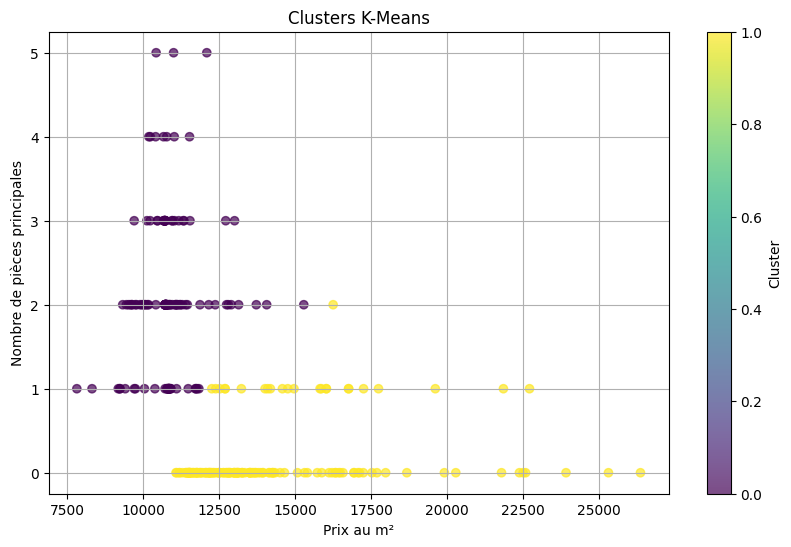

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df3["prix_m2"],
    df3["nombre_pieces_principales"],
    c=df3["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Prix au m²")
plt.ylabel("Nombre de pièces principales")
plt.title("Clusters K-Means")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

On réalise le même exercice en utilisant cette fois les variables 'surface_reelle' et 'prix_m2'

In [ ]:
# Variables retenues
variables_kmeans2 = [
    "surface_reelle",
    "prix_m2"
]

# Construction de X2
X2 = df3[variables_kmeans2]

# Standardisation
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

# Clustering
kmeans2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Attribution des clusters
df3["cluster2"] = kmeans2.fit_predict(X2_scaled)

# Comparaison avec le type réel
pd.crosstab(
    df3["type_local"],
    df3["cluster2"]
)

cluster2,0,1
type_local,,
Appartement,138,16
Local industriel. commercial ou assimilé,88,33


K-Means ne parvient à distinguer correctement les deux types de biens que dans environ 62 % des cas.
On observe notamment :
- 88 locaux commerciaux classés avec les appartements ;
- seulement 33 locaux correctement isolés.

In [ ]:
# Calcul manuel du taux de correspondance
correspondance2 = (138 + 33) / (138 + 16 + 88 + 33)
print(f"{correspondance2:.2%}")

62.18%


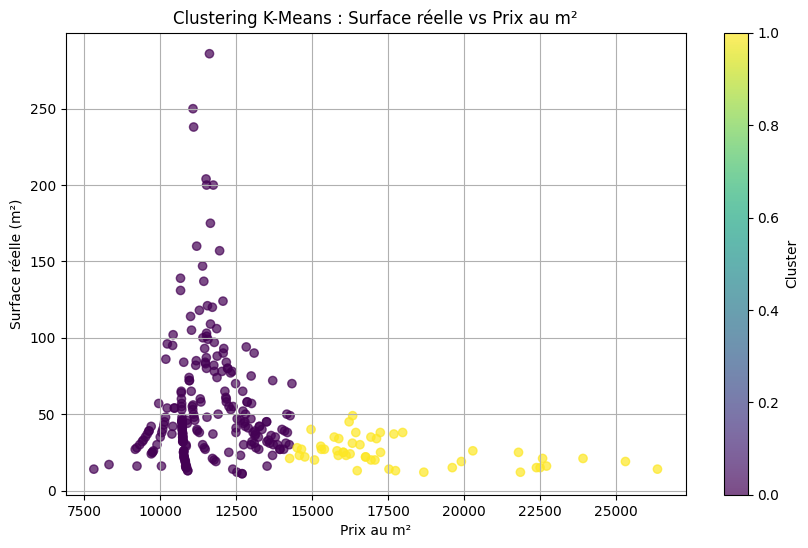

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df3["prix_m2"],
    df3["surface_reelle"],
    c=df3["cluster2"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Prix au m²")
plt.ylabel("Surface réelle (m²)")
plt.title("Clustering K-Means : Surface réelle vs Prix au m²")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

Plusieurs combinaisons de variables ont été testées avec K-Means (K=2). L'utilisation de la surface réelle et du prix au m² conduit à un taux de correspondance de 62 %, montrant une séparation imparfaite des biens. En revanche, l'ajout du nombre de pièces principales permet une bonne séparation des appartements et des locaux commerciaux (91 % de correspondance). Cette variable apparaît donc comme le principal facteur explicatif du type de local dans les données étudiées.

# Milestone 5 - Analyse et présentation des résultats

Ce projet permet d'exploiter un historique de transactions immobilières parisiennes afin de répondre à plusieurs problématiques métier :
- comprendre l'évolution du marché immobilier,
- construire un modèle de valorisation automatique des biens et
- segmenter un portefeuille immobilier à l'aide de techniques de Machine Learning.

L'analyse exploratoire a mis en évidence une hausse globale des prix au mètre carré entre 2017 et 2021 ainsi que des écarts significatifs entre les arrondissements de Paris. Les quartiers centraux présentent les niveaux de valorisation les plus élevés tandis que les arrondissements périphériques affichent des prix plus modérés.

La phase de modélisation a permis de construire un modèle capable d'estimer la valeur foncière de nouveaux biens à partir de leurs caractéristiques. Ce modèle a ensuite été appliqué au portefeuille actif de l'entreprise afin d'obtenir une valorisation estimée de l'ensemble des actifs et une répartition par segment de clientèle.

Enfin, l'utilisation de l'algorithme K-Means a montré qu'il est possible de retrouver automatiquement des groupes de biens cohérents à partir de leurs caractéristiques. Les variables nombre de pièces principales et prix au mètre carré apparaissent comme les plus discriminantes pour distinguer les appartements des locaux commerciaux. Le clustering obtient un taux de correspondance élevé avec les catégories réelles, démontrant la pertinence des variables sélectionnées.
Le clustering a été utilisé ici pour démontrer la capacité de K-Means à retrouver automatiquement des groupes homogènes à partir des caractéristiques des biens. Dans un contexte professionnel, j'utiliserais plutôt cette méthode pour identifier des profils d'investissement ou détecter des biens atypiques que pour reproduire une information déjà disponible

Dans son ensemble, ce projet montre comment les techniques de Data Analysis et de Machine Learning peuvent être utilisées pour produire des indicateurs d'aide à la décision, automatiser certaines analyses immobilières et mieux comprendre la composition d'un portefeuille d'actifs.